<a href="https://colab.research.google.com/github/rudrarpatel22-lang/bank-marketing-ml/blob/main/notebooks/03_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2 — Customer Segmentation with Clustering

## Business objective

The goal is to discover whether meaningful groups of similar **contact records** exist, using only information available before the current call.

This task is connected to Task 1: after the clusters are fixed, the later holdout is used to compare subscription rates and the Task 1 Random Forest score distribution by cluster. The final question is whether segmentation adds practical value to the bank's 500-call campaign strategy.

**Important:** `y`, current-call outcome information, and supervised model predictions are never used as clustering inputs.

## Unit of analysis

The unit of analysis is **one historical contact record / campaign contact opportunity**.

The dataset does not contain a dependable unique customer identifier, so a row is not assumed to represent a unique individual.

The purpose is therefore to segment contact records that look similar at the decision point.

## Feature-selection rationale

The clustering feature set focuses on variables that describe the client/contact situation and past campaign history:

- **Customer characteristics:** age, job, marital status, education, housing and loan status.
- **Past campaign/contact history:** campaign, previous, whether the client was previously contacted, previous-contact recency, and previous campaign outcome.
- **Contact context:** contact channel.

The economic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) and calendar variables (`month`, `day_of_week`) are deliberately excluded from the final clustering representation. The task warns that economic indicators can group records mainly by time period rather than by client characteristics. Removing these variables makes the segmentation more focused on relatively persistent customer/contact characteristics instead of historical economic eras.

`pdays = 999` is treated as a special state meaning that the client was not previously contacted. It is represented using `previously_contacted` and a capped recency variable rather than treating 999 as a real number of days.

## Similarity and preprocessing

Clustering depends on how similarity is represented.

- Numerical variables are median-imputed and standardized so large raw units do not dominate distance.
- Categorical variables are most-frequent imputed and one-hot encoded.
- K-Means therefore uses Euclidean distance in the resulting encoded feature space.
- Agglomerative clustering uses Ward linkage on the same processed representation.

The clusters describe similarity in this chosen representation; they are not a universal definition of customer similarity.

In [2]:
!git clone https://github.com/rudrarpatel22-lang/bank-marketing-ml.git
%cd /content/bank-marketing-ml

Cloning into 'bank-marketing-ml'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 52 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 663.28 KiB | 9.75 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/bank-marketing-ml


In [3]:
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded.")

Libraries loaded.


## 1. Load the dataset

In [4]:
df = pd.read_csv(
    "data/bank-additional-full.csv",
    sep=";",
    quoting=csv.QUOTE_NONE
)
df = df.map(
    lambda x: x.strip('"') if isinstance(x, str) else x
)
df.columns = df.columns.str.strip('"')

df["age"] = pd.to_numeric(df["age"], errors="coerce")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Create the temporal training and holdout periods

The same 80/20 temporal split used for Task 1 is retained.

Clustering is learned from earlier records. The final fitted K-Means model is then used to assign the later records to the already-fixed clusters.

In [5]:
X_all = df.drop(columns=["y", "duration"]).copy()
y_all = df["y"].copy()

split_index = int(len(df) * 0.80)

X_train = X_all.iloc[:split_index].copy()
X_holdout = X_all.iloc[split_index:].copy()

y_train = y_all.iloc[:split_index].copy()
y_holdout = y_all.iloc[split_index:].copy()

print("Training rows:", len(X_train))
print("Holdout rows:", len(X_holdout))

Training rows: 32950
Holdout rows: 8238


## 3. Build the final pre-call clustering feature set

In [6]:
numeric_features = [
    "age",
    "campaign",
    "previous",
    "pdays_capped",
    "previously_contacted"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "contact",
    "poutcome"
]

def make_cluster_features(data):
    result = data.copy()

    result["previously_contacted"] = (result["pdays"] != 999).astype(int)
    result["pdays_capped"] = result["pdays"].replace(999, np.nan).clip(upper=30)

    return result[numeric_features + categorical_features]

X_train_cluster = make_cluster_features(X_train)
X_holdout_cluster = make_cluster_features(X_holdout)

print("Clustering features:", numeric_features + categorical_features)
print("Training clustering shape:", X_train_cluster.shape)
display(X_train_cluster.head())

Clustering features: ['age', 'campaign', 'previous', 'pdays_capped', 'previously_contacted', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'poutcome']
Training clustering shape: (32950, 12)


,age,campaign,previous,pdays_capped,previously_contacted,job,marital,education,housing,loan,contact,poutcome
0,56,1,0,NaN,0,housemaid,married,basic.4y,no,no,telephone,nonexistent
1,57,1,0,NaN,0,services,married,high.school,no,no,telephone,nonexistent
2,37,1,0,NaN,0,services,married,high.school,yes,no,telephone,nonexistent
3,40,1,0,NaN,0,admin.,married,basic.6y,no,no,telephone,nonexistent
4,56,1,0,NaN,0,services,married,high.school,no,yes,telephone,nonexistent


## 4. Preprocess the clustering features

The preprocessor is fitted only on the training period.

The compatibility code below supports both newer and older scikit-learn versions for `OneHotEncoder`.

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train_cluster)
X_holdout_processed = preprocessor.transform(X_holdout_cluster)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (32950, 40)


## 5. Reproducible sampling for expensive clustering diagnostics

The full training period contains about 33,000 records. Silhouette calculations and Agglomerative Clustering are expensive at that size.

The task explicitly allows a reproducible sample for clustering comparisons. A fixed sample of 5,000 training records is therefore used for method comparison, silhouette, and stability.

The final selected K-Means model is fitted on **all training records** after the setting has been selected.

In [8]:
sample_size = min(5000, len(X_train_processed))

sample_rng = np.random.RandomState(RANDOM_STATE)
sample_indices = sample_rng.choice(
    len(X_train_processed),
    size=sample_size,
    replace=False
)

X_cluster_sample = X_train_processed[sample_indices]

print("Diagnostic sample size:", len(X_cluster_sample))
print("Sampling seed:", RANDOM_STATE)

Diagnostic sample size: 5000
Sampling seed: 42


## 6. Compare K-Means settings

In [9]:
kmeans_results = []

for k in [2, 3, 4, 5, 6]:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X_cluster_sample)

    score = silhouette_score(
        X_cluster_sample,
        labels
    )

    sizes = pd.Series(labels).value_counts(normalize=True)

    kmeans_results.append({
        "method": "KMeans",
        "n_clusters": k,
        "silhouette": score,
        "smallest_cluster_pct": sizes.min() * 100
    })

kmeans_results = pd.DataFrame(kmeans_results)

display(
    kmeans_results.sort_values("silhouette", ascending=False)
)

,method,n_clusters,silhouette,smallest_cluster_pct
0,KMeans,2,0.878791,0.14
4,KMeans,6,0.161307,0.14
3,KMeans,5,0.152645,0.14
2,KMeans,4,0.145184,0.14
1,KMeans,3,0.120348,0.14


## 7. Compare Agglomerative Clustering settings

In [10]:
agg_results = []

for k in [2, 3, 4, 5, 6]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_cluster_sample)

    score = silhouette_score(
        X_cluster_sample,
        labels
    )

    sizes = pd.Series(labels).value_counts(normalize=True)

    agg_results.append({
        "method": "Agglomerative",
        "n_clusters": k,
        "silhouette": score,
        "smallest_cluster_pct": sizes.min() * 100
    })

agg_results = pd.DataFrame(agg_results)

display(
    agg_results.sort_values("silhouette", ascending=False)
)

,method,n_clusters,silhouette,smallest_cluster_pct
0,Agglomerative,2,0.878791,0.14
1,Agglomerative,3,0.434255,0.14
2,Agglomerative,4,0.382048,0.14
3,Agglomerative,5,0.271681,0.14
4,Agglomerative,6,0.118726,0.14


## 8. Compare the clustering approaches

In [11]:
cluster_comparison = pd.concat(
    [kmeans_results, agg_results],
    ignore_index=True
).sort_values(
    "silhouette",
    ascending=False
)

display(cluster_comparison)

,method,n_clusters,silhouette,smallest_cluster_pct
0,KMeans,2,0.878791,0.14
5,Agglomerative,2,0.878791,0.14
6,Agglomerative,3,0.434255,0.14
7,Agglomerative,4,0.382048,0.14
8,Agglomerative,5,0.271681,0.14
4,KMeans,6,0.161307,0.14
3,KMeans,5,0.152645,0.14
2,KMeans,4,0.145184,0.14
1,KMeans,3,0.120348,0.14
9,Agglomerative,6,0.118726,0.14


## 9. Test K-Means stability

Stability is evaluated across multiple random seeds using Adjusted Rand Index (ARI).

A higher ARI means that the assignments from two runs are more similar. Stability is considered together with silhouette and cluster size rather than used alone.

In [12]:
stability_rows = []

for k in [2, 3, 4, 5, 6]:
    label_runs = []

    for seed in [1, 7, 21, 42, 99]:
        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=10
        )
        label_runs.append(
            model.fit_predict(X_cluster_sample)
        )

    ari_scores = []

    for i in range(len(label_runs)):
        for j in range(i + 1, len(label_runs)):
            ari_scores.append(
                adjusted_rand_score(
                    label_runs[i],
                    label_runs[j]
                )
            )

    stability_rows.append({
        "method": "KMeans",
        "n_clusters": k,
        "mean_ARI_sample": np.mean(ari_scores),
        "min_ARI_sample": np.min(ari_scores)
    })

stability_results = pd.DataFrame(stability_rows)

display(stability_results)

,method,n_clusters,mean_ARI_sample,min_ARI_sample
0,KMeans,2,0.615541,0.038851
1,KMeans,3,0.982247,0.959654
2,KMeans,4,0.994259,0.990185
3,KMeans,5,0.955576,0.892063
4,KMeans,6,0.991655,0.982838


## 10. Select the final clustering setting

The final method and cluster count are selected using training-period diagnostics only.

The selection rule is:

1. Prefer K-Means because it can assign new holdout observations using `predict()`.
2. Keep candidates with mean stability (ARI) of at least 0.50 when possible.
3. Among those candidates, choose the highest silhouette score.
4. Do not automatically reject small clusters; investigate them after fitting the final model.
5. If no candidate meets the stability screen, choose the highest-silhouette candidate and explicitly report the stability limitation.

This makes the trade-off between separation and stability explicit rather than silently choosing a model using holdout outcomes.


In [13]:
kmeans_selection = kmeans_results.merge(
    stability_results,
    on=["method", "n_clusters"],
    how="left"
)

# Selection rule:
# 1. Do not automatically reject small clusters; inspect them later.
# 2. Prefer K-Means settings with mean ARI >= 0.50.
# 3. Among those, choose the highest silhouette score.
# 4. If no setting passes the stability screen, choose the highest-silhouette setting
#    and explicitly report the stability limitation.

stable_candidates = kmeans_selection[
    kmeans_selection["mean_ARI_sample"] >= 0.50
].copy()

if len(stable_candidates) > 0:
    best_row = stable_candidates.sort_values(
        ["silhouette", "mean_ARI_sample"],
        ascending=False
    ).iloc[0]
else:
    best_row = kmeans_selection.sort_values(
        ["silhouette", "mean_ARI_sample"],
        ascending=False
    ).iloc[0]

FINAL_METHOD = best_row["method"]
FINAL_K = int(best_row["n_clusters"])

print("Selected method:", FINAL_METHOD)
print("Selected K:", FINAL_K)
print("Selected silhouette:", round(best_row["silhouette"], 4))
print("Selected mean ARI:", round(best_row["mean_ARI_sample"], 4))
print(
    "Selected smallest cluster:",
    round(best_row["smallest_cluster_pct"], 2),
    "%"
)

if best_row["smallest_cluster_pct"] < 2:
    print(
        "\nWarning: the selected diagnostic solution contains a small cluster. "
        "The final full-training solution will be inspected separately."
    )

Selected method: KMeans
Selected K: 2
Selected silhouette: 0.8788
Selected mean ARI: 0.6155
Selected smallest cluster: 0.14 %



## 11. Fit the final clustering model on the full training period

The setting was selected using the reproducible diagnostic sample. The final K-Means model is now fitted on **all training records**.

No target or supervised model score is used.

In [14]:
final_cluster_model = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

train_labels = final_cluster_model.fit_predict(
    X_train_processed
)

holdout_labels = final_cluster_model.predict(
    X_holdout_processed
)

print("Final K-Means fitted on full training data.")

Final K-Means fitted on full training data.


## 12. Inspect final cluster sizes

In [15]:
train_cluster_sizes = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
)

cluster_size_table = pd.DataFrame({
    "cluster": train_cluster_sizes.index,
    "count": train_cluster_sizes.values,
    "percentage": (
        train_cluster_sizes.values /
        len(train_labels) * 100
    )
})

cluster_size_table["percentage"] = (
    cluster_size_table["percentage"].round(2)
)

display(cluster_size_table)

tiny_clusters = cluster_size_table[
    cluster_size_table["percentage"] < 2
]

if len(tiny_clusters) == 0:
    print("No final cluster contains less than 2% of training records.")
else:
    print("Potentially tiny final clusters:")
    display(tiny_clusters)

,cluster,count,percentage
0,0,30675,93.1
1,1,2275,6.9


No final cluster contains less than 2% of training records.


## 13. Investigate duplicates, near-duplicates and outliers

Exact duplicates are counted but not automatically removed.

Near-duplicates are investigated using nearest-neighbour distances on a reproducible 1,000-record sample.

For K-Means, observations far from their assigned centroid are also inspected as potential outliers.

In [16]:
duplicate_cluster_features = X_train_cluster.duplicated().sum()

print(
    "Exact duplicate clustering-feature rows:",
    duplicate_cluster_features
)

near_sample_size = min(1000, len(X_train_processed))

near_rng = np.random.RandomState(RANDOM_STATE + 1)

near_indices = near_rng.choice(
    len(X_train_processed),
    size=near_sample_size,
    replace=False
)

X_near_sample = X_train_processed[near_indices]

nearest_model = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean"
)

nearest_model.fit(X_near_sample)

nearest_distances, _ = nearest_model.kneighbors(
    X_near_sample
)

near_duplicate_summary = pd.DataFrame({
    "sample_index": near_indices,
    "nearest_other_distance": nearest_distances[:, 1]
}).sort_values(
    "nearest_other_distance"
)

print("Smallest nearest-neighbour distances:")
display(near_duplicate_summary.head(10))

centroid_distances = final_cluster_model.transform(
    X_train_processed
)

assigned_distance = centroid_distances[
    np.arange(len(centroid_distances)),
    train_labels
]

outlier_table = pd.DataFrame({
    "cluster": train_labels,
    "distance_to_centroid": assigned_distance
}).sort_values(
    "distance_to_centroid",
    ascending=False
)

print("Largest distances to assigned centroid:")
display(outlier_table.head(10))

Exact duplicate clustering-feature rows: 10883
Smallest nearest-neighbour distances:


,sample_index,nearest_other_distance
964,19184,0.0
83,27210,0.0
701,10663,0.0
569,29074,0.0
689,31056,0.0
101,23799,0.0
7,21514,0.0
738,21274,0.0
121,22019,0.0
125,29661,0.0


Largest distances to assigned centroid:


,cluster,distance_to_centroid
32728,1,30.891840
30628,1,30.876534
31340,1,30.871601
32035,1,30.845127
31176,1,30.838948
32669,1,30.838067
31240,1,30.835379
32317,1,30.833024
31846,1,30.820972
30915,1,30.819510


## 14. Profile the final clusters

In [17]:
profile_train = X_train_cluster.copy()
profile_train["cluster"] = train_labels

numeric_profile = (
    profile_train
    .groupby("cluster")[numeric_features]
    .mean()
    .round(2)
)

display(numeric_profile)

,age,campaign,previous,pdays_capped,previously_contacted
cluster,,,,,
0,40.03,2.73,0.00,NaN,0.00
1,40.05,1.89,1.06,5.29,0.08


In [18]:
categorical_profile_rows = []

for cluster_id, group in profile_train.groupby("cluster"):
    row = {"cluster": cluster_id}

    for col in categorical_features:
        mode = group[col].mode(dropna=True)
        row[col] = (
            mode.iloc[0]
            if len(mode) > 0
            else "unknown"
        )

    categorical_profile_rows.append(row)

categorical_profile = pd.DataFrame(
    categorical_profile_rows
)

display(categorical_profile)

,cluster,job,marital,education,housing,loan,contact,poutcome
0,0,admin.,married,university.degree,yes,no,cellular,nonexistent
1,1,blue-collar,married,university.degree,yes,no,cellular,failure


## 15. PCA 2D visualization

PCA is used only to visualize the processed feature space.

The 2D plot is **not proof that the clusters are well separated in the original feature space**.

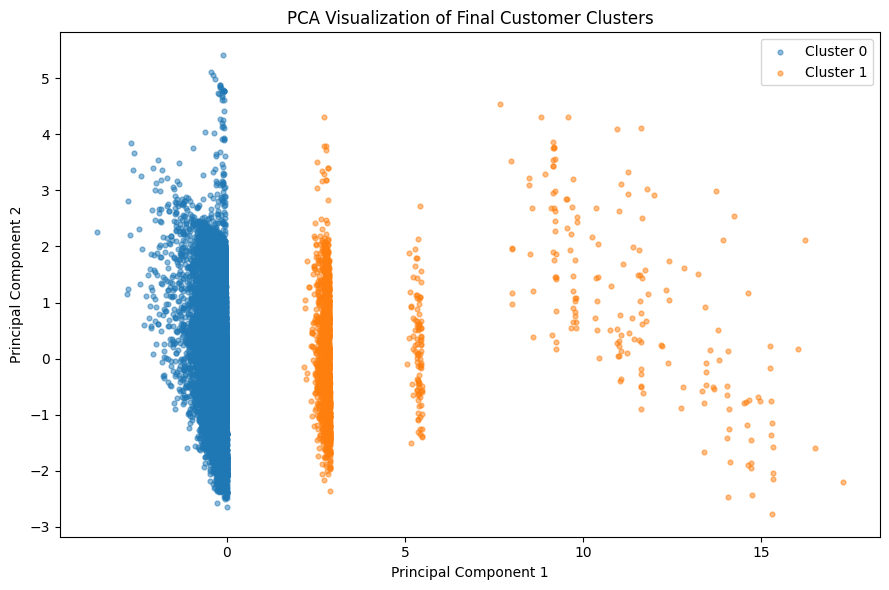

Explained variance ratio: [0.1622443  0.12590665]


In [19]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(
    X_train_processed
)

plt.figure(figsize=(9, 6))

for cluster_id in sorted(np.unique(train_labels)):
    mask = train_labels == cluster_id

    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Final Customer Clusters")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

# Task 2 → Task 1 connection

The clusters are now fixed.

Only **after** fixing the clusters, we connect them to Task 1:

1. Assign the later holdout records to the fixed clusters.
2. Compare actual historical subscription rates by cluster.
3. Reconstruct the Task 1 Random Forest using the same pre-call features and temporal split.
4. Compare the Random Forest score distribution by cluster.
5. Determine whether the segmentation provides information that should change the 500-call strategy.

The Random Forest prediction is never included in the clustering feature matrix.

## 16. Assign the fixed clusters to the later holdout

In [20]:
holdout_cluster_analysis = pd.DataFrame({
    "cluster": holdout_labels,
    "y": y_holdout.values
})

cluster_holdout_summary = (
    holdout_cluster_analysis
    .groupby("cluster")
    .agg(
        holdout_customers=("y", "size"),
        subscribers=(
            "y",
            lambda x: (x == "yes").sum()
        ),
        subscription_rate=(
            "y",
            lambda x: (x == "yes").mean()
        )
    )
    .reset_index()
)

cluster_holdout_summary["subscription_rate_pct"] = (
    cluster_holdout_summary["subscription_rate"] * 100
).round(2)

display(cluster_holdout_summary)

,cluster,holdout_customers,subscribers,subscription_rate,subscription_rate_pct
0,0,4888,1229,0.251432,25.14
1,1,3350,1311,0.391343,39.13


## 17. Reconstruct the Task 1 Random Forest

In [21]:
# Reconstruct the same Random Forest family used in Task 1.
# This makes Task 2 self-contained.

X_supervised = df.drop(
    columns=["y", "duration"]
).copy()

y_supervised = df["y"].copy()

X_train_supervised = X_supervised.iloc[:split_index].copy()
X_holdout_supervised = X_supervised.iloc[split_index:].copy()

y_train_supervised = y_supervised.iloc[:split_index].copy()

supervised_numeric = (
    X_train_supervised
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

supervised_categorical = (
    X_train_supervised
    .select_dtypes(include="object")
    .columns
    .tolist()
)

supervised_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    supervised_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    supervised_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

supervised_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", supervised_encoder)
])

supervised_preprocessor = ColumnTransformer([
    (
        "numeric",
        supervised_numeric_pipeline,
        supervised_numeric
    ),
    (
        "categorical",
        supervised_categorical_pipeline,
        supervised_categorical
    )
])

rf_model = Pipeline([
    ("preprocessor", supervised_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

rf_model.fit(
    X_train_supervised,
    y_train_supervised
)

selected_probability = rf_model.predict_proba(
    X_holdout_supervised
)[:, 1]

print(
    "Random Forest holdout probabilities:",
    len(selected_probability)
)

Random Forest holdout probabilities: 8238


## 18. Compare Task 1 Random Forest scores by fixed cluster

In [22]:
cluster_score_analysis = pd.DataFrame({
    "cluster": holdout_labels,
    "rf_score": selected_probability
})

cluster_score_summary = (
    cluster_score_analysis
    .groupby("cluster")["rf_score"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .round(4)
    .reset_index()
)

display(cluster_score_summary)

,cluster,count,mean,median,min,max
0,0,4888,0.1437,0.135,0.0,0.670
1,1,3350,0.2046,0.189,0.0,0.685


## 19. Combine the Task 1 and Task 2 evidence

In [23]:
combined_cluster_profile = cluster_holdout_summary.merge(
    cluster_score_summary,
    on="cluster",
    how="left"
)

display(combined_cluster_profile)

,cluster,holdout_customers,subscribers,subscription_rate,subscription_rate_pct,count,mean,median,min,max
0,0,4888,1229,0.251432,25.14,4888,0.1437,0.135,0.0,0.670
1,1,3350,1311,0.391343,39.13,3350,0.2046,0.189,0.0,0.685


## 20. Does segmentation change the 500-call strategy?

The supervised Task 1 model ranks customers directly by predicted subscription probability. The clustering analysis is descriptive.

A cluster should change the campaign recommendation only if it adds useful information beyond the ranking model.

We therefore compare:

- the number of holdout records represented by each cluster;
- actual holdout subscription rate;
- mean Random Forest score;
- and whether the highest-value segment is already naturally concentrated among the highest model scores.

A cluster difference is not evidence that changing the campaign treatment would cause more subscriptions. That would require an intervention or campaign experiment.

In [24]:
# Quantify the relationship between the fixed clusters and Task 1 scores.

cluster_score_order = cluster_score_summary.sort_values(
    "mean",
    ascending=False
).reset_index(drop=True)

cluster_rate_order = cluster_holdout_summary.sort_values(
    "subscription_rate",
    ascending=False
).reset_index(drop=True)

rate_range = (
    cluster_holdout_summary["subscription_rate"].max()
    - cluster_holdout_summary["subscription_rate"].min()
)

score_range = (
    cluster_score_summary["mean"].max()
    - cluster_score_summary["mean"].min()
)

holdout_cluster_count = (
    cluster_holdout_summary["cluster"].nunique()
)

print(
    "Number of clusters represented in holdout:",
    holdout_cluster_count
)

print(
    "Difference between highest and lowest holdout subscription rates:",
    round(rate_range * 100, 2),
    "percentage points"
)

print(
    "Difference between highest and lowest mean RF scores:",
    round(score_range, 4)
)

if holdout_cluster_count < FINAL_K:
    verdict = (
        "The fixed training clusters are not all represented in the later holdout. "
        "This weakens their usefulness as persistent campaign segments."
    )
elif rate_range < 0.05:
    verdict = (
        "The clusters do not show a large enough holdout subscription-rate difference "
        "to justify changing the 500-call strategy."
    )
elif score_range < 0.05:
    verdict = (
        "The clusters differ in historical subscription rate, but their Random Forest "
        "score distributions are similar enough that the supervised ranking should remain "
        "the primary 500-call strategy."
    )
else:
    verdict = (
        "The clusters show meaningful descriptive differences in both historical "
        "subscription rates and Random Forest scores. They may add segmentation value, "
        "but the 500-call ranking should still be driven by the supervised model unless "
        "a future intervention test shows that segment-based prioritisation improves outcomes."
    )

print("FINAL SEGMENTATION VERDICT:")
print(verdict)

Number of clusters represented in holdout: 2
Difference between highest and lowest holdout subscription rates: 13.99 percentage points
Difference between highest and lowest mean RF scores: 0.0609
FINAL SEGMENTATION VERDICT:
The clusters show meaningful descriptive differences in both historical subscription rates and Random Forest scores. They may add segmentation value, but the 500-call ranking should still be driven by the supervised model unless a future intervention test shows that segment-based prioritisation improves outcomes.


## 21. Final conclusion

The final conclusion is generated from the evidence above.

The clustering task is considered successful only to the extent that the discovered groups are:

- reasonably stable;
- sufficiently large;
- distinguishable and interpretable;
- persistent enough to appear in the later holdout;
- and useful for understanding the Task 1 campaign ranking.

If the clusters mainly represent historical time/economic regimes or do not persist in the holdout, the appropriate conclusion is that segmentation adds limited practical value.

The supervised Task 1 ranking therefore remains the primary basis for selecting the 500 contacts unless the evidence above demonstrates a clear and defensible reason to use the segments as an additional campaign rule.

## 22. Save the Task 2 evidence

In [25]:
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

cluster_comparison.to_csv(
    "../results/clustering_comparison.csv",
    index=False
)

stability_results.to_csv(
    "../results/clustering_stability.csv",
    index=False
)

cluster_size_table.to_csv(
    "../results/cluster_sizes.csv",
    index=False
)

numeric_profile.to_csv(
    "../results/cluster_numeric_profile.csv"
)

categorical_profile.to_csv(
    "../results/cluster_categorical_profile.csv",
    index=False
)

cluster_holdout_summary.to_csv(
    "../results/cluster_holdout_subscription_rates.csv",
    index=False
)

cluster_score_summary.to_csv(
    "../results/cluster_holdout_rf_score_distribution.csv",
    index=False
)

combined_cluster_profile.to_csv(
    "../results/cluster_holdout_combined_profile.csv",
    index=False
)

near_duplicate_summary.head(100).to_csv(
    "../results/near_duplicate_diagnostic.csv",
    index=False
)

outlier_table.head(100).to_csv(
    "../results/cluster_outlier_diagnostic.csv",
    index=False
)

plt.figure(figsize=(9, 6))

for cluster_id in sorted(np.unique(train_labels)):
    mask = train_labels == cluster_id

    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Final Customer Clusters")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/figures/pca_customer_clusters.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("All Task 2 evidence files and the PCA figure were saved.")

All Task 2 evidence files and the PCA figure were saved.


## 23. Task 2 requirement checklist

This notebook covers the requested Task 2 outputs:

- Unit of analysis is explicitly defined as a contact record.
- A compact pre-call feature set is justified.
- Economic and calendar variables are excluded from the final representation because of the risk of time-driven clustering.
- `y`, current-call outcome information, and supervised model predictions are excluded from clustering inputs.
- Numerical variables are scaled and categorical variables are one-hot encoded.
- K-Means and Agglomerative Clustering are compared.
- Expensive diagnostics use a documented reproducible sample.
- Cluster count is selected from training-period silhouette and stability, followed by cluster-size and profile diagnostics.
- Cluster sizes and profiles are reported.
- Tiny groups, exact duplicates, near-duplicates, and outliers are investigated.
- A labelled 2D PCA visualization is included.
- Final clusters are fitted on the full training period and assigned to the later holdout.
- Task 1 is explicitly connected after the clusters are fixed.
- Held-out subscription rates are compared by cluster.
- The Task 1 Random Forest score distribution is compared by cluster.
- The final section evaluates whether segmentation changes the 500-call strategy.
- A practical segmentation verdict and limitations are stated.
- Results and figures are saved for the Evidence Pack.

## 24. Reproducibility

- Fixed random seed: `42`.
- Same temporal 80/20 split as Task 1.
- Clustering comparison sample: 5,000 training records, selected reproducibly.
- Final K-Means is fitted on all training records.
- Holdout records are assigned using the fitted K-Means model.
- No holdout outcome is used to choose the clustering setting.
- Task 1 Random Forest is reconstructed inside this notebook.
- No raw dataset is uploaded to GitHub by this notebook.